<a href="https://colab.research.google.com/github/acedesci/scanalytics/blob/master/EN/S09_Retail_Analytics/SCA_Mini-Case_Retail_Full_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail analytics - Mini-Case Predictive Model Training
---
*Yossiri Adulyasak*

---

# Retail predictive model pipeline for multi-item predictions

This is the full version of the Module 1 (predictive model) for session 8 which extend the simplified version of one item to multiple items.

We begin by loading the required packages.

In [1]:
import pandas as pd  # Library for data manipulation (DataFrames)
import numpy as np   # Library for numerical operations (needed for square roots, etc.)

# Import specific machine learning models
import xgboost as xgb        # XGBoost: Optimized Gradient Boosting library
import lightgbm as lgb       # LightGBM: Another high-performance Gradient Boosting library
from sklearn.linear_model import LinearRegression  # Basic Linear Regression
from sklearn.ensemble import RandomForestRegressor # Random Forest (ensemble of trees)
from sklearn.ensemble import HistGradientBoostingRegressor # Gradient boosting trees in sklearn

# Import metrics to measure how accurate our predictions are
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error



## *Custom function - Error calculations

First, we create a function to measure the quality of predictions

In [2]:
def evaluate_model(model_name, y_true, y_pred):
    # MAE: Average absolute difference. Easy to interpret (e.g., "off by 20 units").
    mae = mean_absolute_error(y_true, y_pred)

    # RMSE: Root Mean Squared Error. Penalizes large errors more than MAE.
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE: Mean Absolute Percentage Error. Shows error as a % of actual sales.
    # We use numpy (np) to calculate: mean( abs( (Actual - Pred) / Actual ) ) * 100
    mape = np.mean(np.abs((y_true - y_pred) / (y_true))) * 100

    # wMAPE: Weighted MAPE. Sum of Absolute Errors divided by the Sum of Actual Values
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    # ME: mean error to show the average bias
    me = np.mean(y_pred - y_true)

    # R2: How well the model explains the variance. 1.0 is perfect, 0.0 is useless.
    r2 = r2_score(y_true, y_pred)

    # Print the formatted results
    print(f"{model_name:20} | MAE: {mae:6.2f} | RMSE: {rmse:6.2f} | MAPE: {mape:6.2f}% | wMAPE: {wmape:6.2f}% | ME: {me:6.2f}%| R2: {r2:.4f}")

# Block 1: Data input

In [3]:
# -------------------------------------------------------------------------
# LOAD AND PREPARE DATA
# -------------------------------------------------------------------------
URL = 'https://raw.githubusercontent.com/acedesci/scanalytics/refs/heads/master/EN/S08_09_Retail_Analytics/data/cereals_data_full.csv'
df = pd.read_csv(URL)
# Drop any rows that have missing values (NaN).
df = df.dropna()

# Calculate the discount column from 'BASE_PRICE' and 'PRICE'
df['DISCOUNT'] = (df['BASE_PRICE'] - df['PRICE']) / df['BASE_PRICE']

# Convert the 'WEEK_END_DATE' column from string format to a datetime object. This allows us to sort the data chronologically.
df['WEEK_END_DATE'] = pd.to_datetime(df['WEEK_END_DATE'])

# Extract Week Number (1-53) to capture seasonality
df['WEEK_NUM'] = df['WEEK_END_DATE'].dt.isocalendar().week.astype(int)

# Sort the dataset by date. This is CRITICAL for time-series splits as we want to train on the "past" and test on the "future".
df = df.sort_values('WEEK_END_DATE')
df

,WEEK_END_DATE,STORE_NUM,UPC,UNITS,VISITS,HHS,SPEND,PRICE,BASE_PRICE,FEATURE,DISPLAY,TPR_ONLY,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE,DISCOUNT,WEEK_NUM
0,2009-01-14,367,1111085319,14,13,13,26.32,1.88,1.88,0,0,0,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ,0.000000,3
457,2009-01-14,21213,3800039118,32,31,31,86.08,2.69,3.32,1,1,0,KELLOGG,COLD CEREAL,KIDS CEREAL,12 OZ,0.189759,3
458,2009-01-14,21221,1111085319,15,13,13,28.20,1.88,1.88,0,0,0,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ,0.000000,3
459,2009-01-14,21221,1111085345,35,30,29,65.45,1.87,1.87,0,0,0,PRIVATE LABEL,COLD CEREAL,ADULT CEREAL,18 OZ,0.000000,3
460,2009-01-14,21221,1111085350,71,53,52,139.16,1.96,1.96,0,0,0,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.000000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138178,2012-01-04,10019,1111085345,17,12,12,27.54,1.62,1.62,0,0,0,PRIVATE LABEL,COLD CEREAL,ADULT CEREAL,18 OZ,0.000000,1
138179,2012-01-04,10019,1111085350,4,3,3,8.88,2.22,2.22,0,0,0,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,18 OZ,0.000000,1
138180,2012-01-04,10019,1600027527,82,71,71,163.18,1.99,2.68,0,0,1,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12 OZ,0.257463,1
138182,2012-01-04,10019,1600027564,17,16,16,51.34,3.02,3.02,0,0,0,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12 OZ,0.000000,1


# Block 2: Data preparation

We need to select the features and split the data. Some input features will be transformed later since some models (linear regression and random forest) use dummy encoding while advanced models (XGBoost and LightGBM) simply require the column to be in categorical type (no need to transform the variable).

In [4]:
# Get a list of all unique weeks in the dataset
unique_weeks = df['WEEK_END_DATE'].unique()

# Calculate the index for the 80% mark.
# We will use the first 80% of weeks for training, last 20% for testing.
split_idx = int(len(unique_weeks) * 0.75)

# Identify the specific date that separates train and test
split_date = unique_weeks[split_idx]

print(f"Splitting data at date: {split_date}")

# Create "Masks" (lists of True/False values) to filter the data.
# train_mask is True for all dates BEFORE the split date.
train_mask = df['WEEK_END_DATE'] < split_date
# test_mask is True for all dates ON or AFTER the split date.
test_mask = df['WEEK_END_DATE'] >= split_date

# --------------------------------------------------------------------------------
# DEFINE TARGET AND FEATURES
# --------------------------------------------------------------------------------
# The column we want to predict
target = 'UNITS'

# List of columns to exclude from the input features (X).
# - 'UNITS': This is the target, so we cannot use it to predict itself.
# - 'WEEK_END_DATE': The model doesn't understand dates directly, and we used it for splitting. We will use 'WEEK_NUM' instead.
# - 'SPEND', 'VISITS', 'HHS': These are "Data Leakage". They only exist *after* sales happen.
# - 'UPC' we want to demonstrate the attribute-based predictive model so that UPC is not directly used

# Define features to use (excluding UPC)
feature_cols = ['PRICE', 'BASE_PRICE','DISCOUNT', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'WEEK_NUM',
            'STORE_NUM', 'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']
# Identify the position of categorical features for the GBM model
# Encode categorical variables as 'category' (this works when using applicable models that support categorial variables)
categorical_columns = ['FEATURE', 'DISPLAY', 'TPR_ONLY', 'WEEK_NUM', 'STORE_NUM',
                       'MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']

# Create the Feature Matrix (X) from selected columns
X = df[feature_cols]

# Create the Target Vector (y) containing only the thing we want to predict
y = df[target]

X

Splitting data at date: 2011-04-13 00:00:00


,PRICE,BASE_PRICE,DISCOUNT,FEATURE,DISPLAY,TPR_ONLY,WEEK_NUM,STORE_NUM,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE
0,1.88,1.88,0.000000,0,0,0,3,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
457,2.69,3.32,0.189759,1,1,0,3,21213,KELLOGG,COLD CEREAL,KIDS CEREAL,12 OZ
458,1.88,1.88,0.000000,0,0,0,3,21221,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
459,1.87,1.87,0.000000,0,0,0,3,21221,PRIVATE LABEL,COLD CEREAL,ADULT CEREAL,18 OZ
460,1.96,1.96,0.000000,0,0,0,3,21221,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,18 OZ
...,...,...,...,...,...,...,...,...,...,...,...,...
138178,1.62,1.62,0.000000,0,0,0,1,10019,PRIVATE LABEL,COLD CEREAL,ADULT CEREAL,18 OZ
138179,2.22,2.22,0.000000,0,0,0,1,10019,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,18 OZ
138180,1.99,2.68,0.257463,0,0,1,1,10019,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
138182,3.02,3.02,0.000000,0,0,0,1,10019,GENERAL MI,COLD CEREAL,ALL FAMILY CEREAL,12 OZ


# Block 3: Model & algorithm (training & testing) - all global models

In the next code cell, we train and test Global Linear Regression and Tree Regression models. These models use all the selected features where the categorial variables (STORE_NUM and UPC) are first transformed into dummy variables. We train each model and test its performance on unseen data (test).

### Linear regression and random forest models

In [5]:
# --------------------------------------------------------------------------------
# MODEL GROUP A: ONE-HOT/DUMMY ENCODING (For Linear Reg & Random Forest)
# --------------------------------------------------------------------------------
# Convert categorical IDs (STORE_NUM, UPC) into binary columns (0 or 1).
# Example: STORE_367 becomes a column. 1 if it's store 367, 0 otherwise.
# drop_first=True removes the first category (dummy encoding) to prevent multicollinearity
X_ohe = pd.get_dummies(X, columns=categorical_columns, drop_first=True)

# Apply the time-based masks to split the One-Hot Encoded data
X_train_ohe = X_ohe[train_mask] # Past data
X_test_ohe = X_ohe[test_mask]   # Future data
y_train = y[train_mask]         # Past targets
y_test = y[test_mask]           # Future targets

# --- Model 1: Linear Regression ---
lr = LinearRegression()         # Initialize the model
lr.fit(X_train_ohe, y_train)    # Train on the past data
pred_lr = lr.predict(X_test_ohe)   # Predict the future data
evaluate_model("Linear Regression", y_test, pred_lr) # Measure performance

# --- Model 2: Random Forest ---
# Limit number of trees and tree depth to prevent overfitting and reduce training time
rf = RandomForestRegressor(n_estimators=25, max_depth=10, min_samples_leaf=10, random_state=0)
rf.fit(X_train_ohe, y_train)
pred_rf = rf.predict(X_test_ohe)
evaluate_model("Random Forest", y_test, pred_rf)

# --- Model 3: Linear Regression with log(PRICE) and log(UNITS) ---
# Create log-transformed columns for price and units
# We copy the OHE data but swap Price columns with Log-Price columns
X_log = X_ohe.copy()
X_log['PRICE'] = np.log(df['PRICE'])            # Replace Price with Log(Price)
y_log = np.log(df['UNITS'])                     # Replace Units with Log(Units)

X_train_log = X_log[train_mask]
X_test_log = X_log[test_mask]
y_train_log = y_log[train_mask] # Target is Log(Units)
y_test_log = y_log[test_mask]   # (Used for internal metrics, we exp() later)

lr_log = LinearRegression()
lr_log.fit(X_train_log, y_train_log)
# Predict Log(Units) -> Exponentiate to get Units
pred_log_raw = lr_log.predict(X_test_log)
pred_lr_log = np.exp(pred_log_raw)
evaluate_model("Log-Log Regression ", y_test, pred_lr_log)

Linear Regression    | MAE:  15.99 | RMSE:  28.62 | MAPE:  69.81% | wMAPE:  44.52% | ME:  -1.48%| R2: 0.5409
Random Forest        | MAE:  17.07 | RMSE:  29.63 | MAPE:  90.58% | wMAPE:  47.53% | ME:  -0.50%| R2: 0.5082
Log-Log Regression   | MAE:  14.15 | RMSE:  26.88 | MAPE:  54.69% | wMAPE:  39.41% | ME:  -5.11%| R2: 0.5953


### XGBoost, LightGBM and skGBM models

In the next code cell, we train and test three advanced ML models, XG Boost, Light GBM and GBM from sklearn. These models only require that the categorical variables are indicated as "category" type (no dummy encoding needed!).

In [6]:
# --------------------------------------------------------------------------------
# MODEL GROUP B: NATIVE CATEGORICAL (For XGBoost & LightGBM & skGBM)
# --------------------------------------------------------------------------------
# Create a copy of the original X so we don't mess up the previous data
X_cat = X.copy()

# Loop through the ID columns and force them to be the 'category' data type.
# This tells the libraries "These are categories, treat them specially."
for col in categorical_columns:
    X_cat[col] = X_cat[col].astype('category')

# Apply the SAME time-based masks (so we are comparing apples to apples)
X_train_cat = X_cat[train_mask]
X_test_cat = X_cat[test_mask]
# Note: y_train and y_test are exactly the same as above, so we reuse them.

# --- Model 3: XGBoost ---
# enable_categorical=True: Activates the special handling for category types
xg_reg = xgb.XGBRegressor(enable_categorical=True, random_state=0)
xg_reg.fit(X_train_cat, y_train)
pred_xgb = xg_reg.predict(X_test_cat)
evaluate_model("XGBoost", y_test, pred_xgb)

# --- Model 4: LightGBM ---
# LightGBM automatically detects 'category' dtype. We indicate 'verbosity = -1' so the log is not displayed
lgbm_reg = lgb.LGBMRegressor(random_state=0, verbosity=-1)
lgbm_reg.fit(X_train_cat, y_train)
pred_lgbm = lgbm_reg.predict(X_test_cat)
evaluate_model("LightGBM", y_test, pred_lgbm)

# --- Model 5: sklearn GBM ---
skgbm_reg = HistGradientBoostingRegressor(categorical_features=categorical_columns, random_state=0)
skgbm_reg.fit(X_train_cat, y_train)
pred_skgbm = skgbm_reg.predict(X_test_cat)
evaluate_model("sklearn GBM", y_test, pred_skgbm)

XGBoost              | MAE:  12.73 | RMSE:  24.68 | MAPE:  53.94% | wMAPE:  35.46% | ME:  -0.71%| R2: 0.6587
LightGBM             | MAE:  12.31 | RMSE:  22.99 | MAPE:  54.82% | wMAPE:  34.28% | ME:  -0.50%| R2: 0.7039
sklearn GBM          | MAE:  12.41 | RMSE:  23.44 | MAPE:  54.79% | wMAPE:  34.57% | ME:  -0.44%| R2: 0.6922


# Block 4: Final model selection

Now we will select the best model and train it again using the entire data for future predictions

In [7]:
# choose LGBM as the final model and train again using the entire data (since now we know it is the best model from cross-validation)
final_model = lgb.LGBMRegressor(random_state=0)
final_model.fit(X_cat, y)

# This will be the final model we used for future demand predictions (in the future and not the test set)

LGBMRegressor(random_state=0)

# [Supplement]
The following parts are supplemental to demonstrate the full pipeline. You mainly need to run and understand the outputs from each process.



### Annex 1: Price-demand curves
The code below shows the plot of price-demand curves from all the models on the test set.

In [8]:
price_variation = df.groupby(['STORE_NUM', 'UPC'])['PRICE'].std()
print("Price Variation (Standard Deviation of Price per Store-UPC combination):")
price_variation.sort_values(ascending=False).head(15)

Price Variation (Standard Deviation of Price per Store-UPC combination):


,,PRICE
STORE_NUM,UPC,
15541,1600027528,0.641008
2281,1600027528,0.624553
28909,1600027528,0.607715
15531,1600027528,0.606362
2541,1600027528,0.602985
23067,1600027528,0.594689
6179,1600027528,0.594670
8041,1600027528,0.590963
11757,1600027528,0.589273


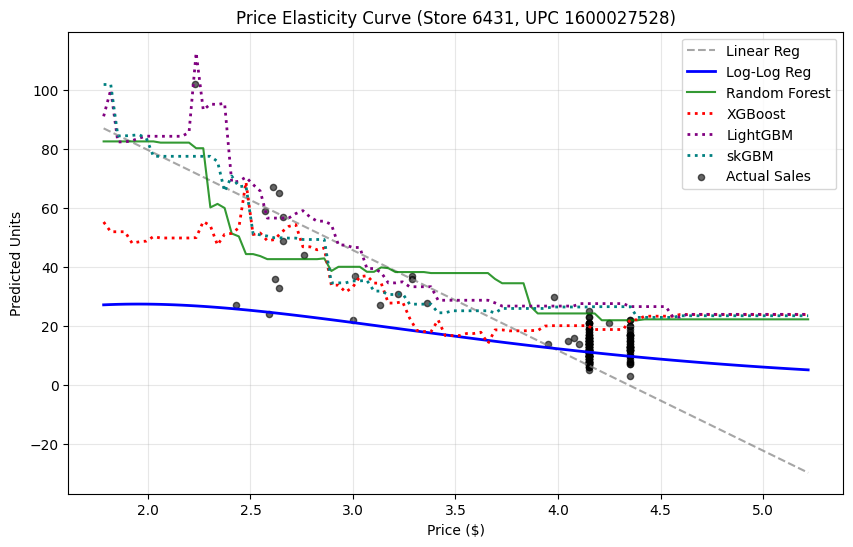

In [9]:
# Setup Data (One Store, One UPC, varying Price)
sample_store = 6431
sample_upc = 1600027528

# Get all data for our target pair
target_mask = (df['STORE_NUM'] == sample_store) & (df['UPC'] == sample_upc)
item_store_df = df[target_mask].copy()

# Create a range of prices for the response curve plot
prices = np.linspace(item_store_df['PRICE'].min()*0.8, item_store_df['PRICE'].max()*1.2, 100)

# retrieve base price using the last one in the data
sample_base_price = item_store_df['BASE_PRICE'].iloc[-1]
discounts = (sample_base_price - prices) / sample_base_price

# ['STORE_NUM', 'PRICE', 'DISCOUNT', 'FEATURE', 'DISPLAY', 'TPR_ONLY', 'MANUFACTURER', 'SUB_CATEGORY', 'PRODUCT_SIZE', 'WEEK_NUM']
sample_upc_attributes = item_store_df[['MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']].drop_duplicates()

# Find the attributes of that sampled UPC
if not sample_upc_attributes.empty:
    sample_manufacturer = sample_upc_attributes['MANUFACTURER'].iloc[0]
    sample_category = sample_upc_attributes['CATEGORY'].iloc[0]
    sample_sub_category = sample_upc_attributes['SUB_CATEGORY'].iloc[0]
    sample_product_size = sample_upc_attributes['PRODUCT_SIZE'].iloc[0]
curve_df = pd.DataFrame({
    'PRICE': prices,
    'BASE_PRICE': sample_base_price,
    'DISCOUNT': discounts,
    'FEATURE': 1, 'DISPLAY': 0, 'TPR_ONLY': 0,
    'WEEK_NUM': 1,
    'STORE_NUM': sample_store,
    'MANUFACTURER': sample_manufacturer,
    'CATEGORY': sample_category,
    'SUB_CATEGORY': sample_sub_category,
    'PRODUCT_SIZE': sample_product_size
})

# Align OHE (Linear & RF)
curve_ohe = pd.get_dummies(curve_df, columns=categorical_columns, drop_first=True)
ohe_cols = X_ohe.columns # Define ohe_cols from the training data columns
curve_ohe = curve_ohe.reindex(columns=ohe_cols, fill_value=0)

# Align Log (Log-Log)
curve_log = curve_ohe.copy()
curve_log['PRICE'] = np.log(curve_df['PRICE'])      # Log Transform Price

# Align Categorical (XGB/LGBM)
curve_cat = curve_df.copy()

for col in categorical_columns:
    curve_cat[col] = curve_cat[col].astype('category')

# Get Predictions
p_lin = lr.predict(curve_ohe)
p_log = np.exp(lr_log.predict(curve_log)) # Remember to Exp()!
p_rf = rf.predict(curve_ohe)
p_xgb = xg_reg.predict(curve_cat)
p_lgbm = lgbm_reg.predict(curve_cat)
p_skgbm = skgbm_reg.predict(curve_df)

# Plot
import matplotlib.pyplot as plt # Import matplotlib
plt.figure(figsize=(10, 6))
plt.plot(prices, p_lin, label='Linear Reg', linestyle='--', color='gray', alpha=0.7)
plt.plot(prices, p_log, label='Log-Log Reg', linestyle='-', color='blue', linewidth=2)
plt.plot(prices, p_rf, label='Random Forest', linestyle='-', color='green', alpha=0.8)
plt.plot(prices, p_xgb, label='XGBoost', linestyle=':', color='red', linewidth=2)
plt.plot(prices, p_lgbm, label='LightGBM', linestyle=':', color='purple', linewidth=2)
plt.plot(prices, p_skgbm, label='skGBM', linestyle=':', color='teal', linewidth=2)

# ADDED: Plot actual data points
actual_data = df[(df['STORE_NUM'] == sample_store) & (df['UPC'] == sample_upc)]
plt.scatter(actual_data['PRICE'], actual_data['UNITS'], label='Actual Sales', color='black', alpha=0.6, s=20)

plt.title(f'Price Elasticity Curve (Store {sample_store}, UPC {sample_upc})')
plt.xlabel('Price ($)')
plt.ylabel('Predicted Units')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Annex 2A: Preparing feature inputs used for future predictions
In order to predict, we need to create input features with varying prices and then use `final_model` to perform predictions

In [10]:
# Forecast future sales of store 367 the week following the last week in the data for the prices ranging from 1.5 to 5.5 with a given increment
#predict_prices = np.arange(1.0, 4.0, 0.25)

predict_store = 367
week = 25
# Prepare the list of UPCs
predict_upcs = df['UPC'].unique()
predict_input_rows = []

# print(df[df['UPC'] == predict_upcs[0]][['MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']].drop_duplicates())

for u in predict_upcs:
  # Retrieve base price and attributes for the current UPC
  target_store_upc = (df['STORE_NUM'] == predict_store) & (df['UPC'] == u)
  reference_base_price = df[target_store_upc]['BASE_PRICE'].max()
  predict_prices = np.linspace(df[target_store_upc]['PRICE'].min()*0.9, df[target_store_upc]['PRICE'].max()*1.1, 10)
  upc_attributes = df[target_store_upc][['MANUFACTURER', 'CATEGORY', 'SUB_CATEGORY', 'PRODUCT_SIZE']].drop_duplicates()

  for p in predict_prices:
    discount = (reference_base_price - p) / reference_base_price

    for f in [0,1]:
      for d in [0,1]:
        # Find the attributes of that UPC
        if not upc_attributes.empty:
            upc_manufacturer = upc_attributes['MANUFACTURER'].iloc[0]
            upc_category = upc_attributes['CATEGORY'].iloc[0]
            upc_sub_category = upc_attributes['SUB_CATEGORY'].iloc[0]
            upc_product_size = upc_attributes['PRODUCT_SIZE'].iloc[0]

        row = {
            'UPC': u,
            'PRICE': p,
            'BASE_PRICE': reference_base_price,
            'DISCOUNT': discount,
            'FEATURE': f, 'DISPLAY': d, 'TPR_ONLY': 0,
            'WEEK_NUM': week,
            'STORE_NUM': predict_store,
            'MANUFACTURER': upc_manufacturer,
            'CATEGORY': upc_category,
            'SUB_CATEGORY': upc_sub_category,
            'PRODUCT_SIZE': upc_product_size,
          }
        predict_input_rows.append(row)


# Create a DataFrame from the list of rows
f_df = pd.DataFrame(predict_input_rows)

f_df.head(25)

,UPC,PRICE,BASE_PRICE,DISCOUNT,FEATURE,DISPLAY,TPR_ONLY,WEEK_NUM,STORE_NUM,MANUFACTURER,CATEGORY,SUB_CATEGORY,PRODUCT_SIZE
0,1111085319,1.440000,1.99,0.276382,0,0,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
1,1111085319,1.440000,1.99,0.276382,0,1,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
2,1111085319,1.440000,1.99,0.276382,1,0,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
3,1111085319,1.440000,1.99,0.276382,1,1,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
4,1111085319,1.523222,1.99,0.234562,0,0,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
5,1111085319,1.523222,1.99,0.234562,0,1,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
6,1111085319,1.523222,1.99,0.234562,1,0,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
7,1111085319,1.523222,1.99,0.234562,1,1,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
8,1111085319,1.606444,1.99,0.192741,0,0,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ
9,1111085319,1.606444,1.99,0.192741,0,1,0,25,367,PRIVATE LABEL,COLD CEREAL,ALL FAMILY CEREAL,12 OZ


### Annex 2B: Predicting the future demands
We will predict the future demands based on different prices for the selected store

In [11]:
# repeat the same transformation process (for the category columns) and then predict the sales
f_X = f_df.copy()

# Ensure f_X has the exact same columns and order as the training data X_cat
f_X = f_X[X_cat.columns]

# Ensure categorical columns have the same categories as the training data
for col in categorical_columns:
    f_X[col] = f_X[col].astype('category')

f_df['PREDICTED_UNITS'] = final_model.predict(f_X)

print("\nForecast Matrix (with Feature split):")

f_df[['UPC','STORE_NUM','PRICE','DISCOUNT','FEATURE','DISPLAY','WEEK_NUM','PREDICTED_UNITS']].head(25)


Forecast Matrix (with Feature split):


,UPC,STORE_NUM,PRICE,DISCOUNT,FEATURE,DISPLAY,WEEK_NUM,PREDICTED_UNITS
0,1111085319,367,1.440000,0.276382,0,0,25,50.212810
1,1111085319,367,1.440000,0.276382,0,1,25,77.412127
2,1111085319,367,1.440000,0.276382,1,0,25,62.477969
3,1111085319,367,1.440000,0.276382,1,1,25,92.458959
4,1111085319,367,1.523222,0.234562,0,0,25,49.327826
5,1111085319,367,1.523222,0.234562,0,1,25,77.049497
6,1111085319,367,1.523222,0.234562,1,0,25,61.592985
7,1111085319,367,1.523222,0.234562,1,1,25,92.096330
8,1111085319,367,1.606444,0.192741,0,0,25,24.106842
9,1111085319,367,1.606444,0.192741,0,1,25,50.653884


### Annex 2C: Price optimization
Calculate expected revenues and find optimal prices under different settings of `FEATURE` and `DISPLAY` and export the output into csv file.

In [12]:
from google.colab import files

# First, we add a column that gives the cost
# For this case, we assume that the cost is $1.5 per unit
f_df['COST'] = 1.5

# Calculate the revenue and profit for each entry
f_df['REVENUE'] = f_df['PRICE']  * f_df['PREDICTED_UNITS']
f_df['PROFIT'] = (f_df['PRICE'] - f_df['COST'])  * f_df['PREDICTED_UNITS']

# Calculate the optimal price for each UPC and FEATURE combination that maximizes REVENUE
# idxmax() returns the index associated with highest target ('REVENUE' column) for each UPC
optimal_revenue_prices = f_df.loc[f_df.groupby(['UPC', 'FEATURE', 'DISPLAY'])['PROFIT'].idxmax()]

colummns_to_display = ['UPC','STORE_NUM','PRICE','DISCOUNT','FEATURE','DISPLAY','WEEK_NUM','PREDICTED_UNITS','REVENUE', 'PROFIT']
optimal_revenue_prices[colummns_to_display]

,UPC,STORE_NUM,PRICE,DISCOUNT,FEATURE,DISPLAY,WEEK_NUM,PREDICTED_UNITS,REVENUE,PROFIT
24,1111085319,367,1.939333,0.025461,0,0,25,19.358060,37.541730,8.504641
37,1111085319,367,2.189000,-0.100000,0,1,25,42.709778,93.491703,29.427037
38,1111085319,367,2.189000,-0.100000,1,0,25,29.683853,64.977955,20.452175
39,1111085319,367,2.189000,-0.100000,1,1,25,64.652136,141.523527,44.545322
116,1111085345,367,2.189000,-0.100000,0,0,25,14.387129,31.493426,9.912732
117,1111085345,367,2.189000,-0.100000,0,1,25,43.048873,94.233984,29.660674
118,1111085345,367,2.189000,-0.100000,1,0,25,29.724508,65.066947,20.480186
119,1111085345,367,2.189000,-0.100000,1,1,25,62.438843,136.678626,43.020363
148,1111085350,367,2.494333,-0.001740,0,0,25,16.311924,40.687377,16.219490
157,1111085350,367,2.739000,-0.100000,0,1,25,41.623635,114.007135,51.571683


In [13]:
# Display the results
print("Optimal Prices for Maximum Weekly Revenue:")
# we first select only the important columns and then sort the results
df_optimal_prices = optimal_revenue_prices[colummns_to_display].sort_values(['UPC', 'FEATURE'])
display(df_optimal_prices)

filename = 'optimal_prices.csv'
df_optimal_prices.to_csv(filename, index=False)
files.download(filename)


Optimal Prices for Maximum Weekly Revenue:


,UPC,STORE_NUM,PRICE,DISCOUNT,FEATURE,DISPLAY,WEEK_NUM,PREDICTED_UNITS,REVENUE,PROFIT
24,1111085319,367,1.939333,0.025461,0,0,25,19.358060,37.541730,8.504641
37,1111085319,367,2.189000,-0.100000,0,1,25,42.709778,93.491703,29.427037
38,1111085319,367,2.189000,-0.100000,1,0,25,29.683853,64.977955,20.452175
39,1111085319,367,2.189000,-0.100000,1,1,25,64.652136,141.523527,44.545322
116,1111085345,367,2.189000,-0.100000,0,0,25,14.387129,31.493426,9.912732
117,1111085345,367,2.189000,-0.100000,0,1,25,43.048873,94.233984,29.660674
118,1111085345,367,2.189000,-0.100000,1,0,25,29.724508,65.066947,20.480186
119,1111085345,367,2.189000,-0.100000,1,1,25,62.438843,136.678626,43.020363
148,1111085350,367,2.494333,-0.001740,0,0,25,16.311924,40.687377,16.219490
157,1111085350,367,2.739000,-0.100000,0,1,25,41.623635,114.007135,51.571683


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Annex 2D: Pivot Table for combined features to be used for optimization

Pivot the prepared data to create a new table where each row represents a unique UPC, and the columns represent the four combinations of 'FEATURE' and 'DISPLAY' (0,0), (0,1), (1,0), and (1,1). The values in these columns will be the corresponding optimal revenues. This format will be exported to Excel as inputs for an optimization model for optimal price and strategy (`FEATURE` and `DISPLAY`) selections.


In [14]:
revenue_data = optimal_revenue_prices[['UPC', 'FEATURE', 'DISPLAY', 'PROFIT']].copy()
revenue_data['FEATURE_DISPLAY_COMBINATION'] = 'FEATURE=' + revenue_data['FEATURE'].astype(str) + ', DISPLAY=' + revenue_data['DISPLAY'].astype(str)
revenue_table = revenue_data.pivot_table(index='UPC', columns='FEATURE_DISPLAY_COMBINATION', values='PROFIT')
revenue_table


FEATURE_DISPLAY_COMBINATION,"FEATURE=0, DISPLAY=0","FEATURE=0, DISPLAY=1","FEATURE=1, DISPLAY=0","FEATURE=1, DISPLAY=1"
UPC,,,,
1111085319,8.504641,29.427037,20.452175,44.545322
1111085345,9.912732,29.660674,20.480186,43.020363
1111085350,16.219490,51.571683,37.354039,78.087072
1600027527,25.754417,65.854399,73.326011,122.809695
1600027528,61.498382,123.596645,138.312409,215.372774
1600027564,26.476156,66.460612,72.224745,119.266435
3800031829,46.023122,92.892203,91.700123,159.534016
3800031838,32.924877,74.434276,69.365151,131.761492
3800039118,26.263209,63.250622,56.623934,114.822817


In [15]:
from google.colab import files

# 1. Display the revenue_table DataFrame
print("\nRevenue Table:")
display(revenue_table.head())

# 2. Save the revenue_table DataFrame to a CSV file
filename = 'profit_promo_table.csv'
revenue_table.to_csv(filename, index=True)

# 3. Download the 'profit_promo_table.csv' file
files.download(filename)


Revenue Table:


FEATURE_DISPLAY_COMBINATION,"FEATURE=0, DISPLAY=0","FEATURE=0, DISPLAY=1","FEATURE=1, DISPLAY=0","FEATURE=1, DISPLAY=1"
UPC,,,,
1111085319,8.504641,29.427037,20.452175,44.545322
1111085345,9.912732,29.660674,20.480186,43.020363
1111085350,16.219490,51.571683,37.354039,78.087072
1600027527,25.754417,65.854399,73.326011,122.809695
1600027528,61.498382,123.596645,138.312409,215.372774


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>